In [ ]:
!pip install xgboost -q

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving rotating_disk_failure_dataset.csv to rotating_disk_failure_dataset.csv


In [ ]:
df = pd.read_csv("rotating_disk_failure_dataset.csv")

print(df.shape)
df.head()

(50000, 14)


,density,young_modulus,poisson_ratio,yield_strength,inner_radius,outer_radius,thickness,rpm,omega,hoop_stress,radial_stress,von_mises,factor_of_safety,failure
0,4685.062630,1.970855e+11,0.308078,2.226723e+08,0.092388,0.950147,0.012067,6842.666106,716.562319,8.980289e+08,5.388173e+08,7.828834e+08,0.284426,1
1,7738.785824,1.441776e+11,0.302697,7.649816e+08,0.118801,0.258622,0.009298,8086.252305,846.790361,1.532271e+08,9.193623e+07,1.335802e+08,5.726757,0
2,6579.567892,9.931984e+10,0.285104,9.888122e+08,0.064882,0.349104,0.011207,5802.665011,607.653659,1.215849e+08,7.295092e+07,1.059952e+08,9.328836,0
3,5872.889966,1.804963e+11,0.299321,9.526967e+08,0.117026,0.719577,0.026307,13773.114467,1442.317174,2.608930e+09,1.565358e+09,2.274413e+09,0.418876,1
4,3526.898794,1.328017e+11,0.286510,1.029266e+09,0.080462,0.547769,0.044804,10910.591908,1142.554513,5.675267e+08,3.405160e+08,4.947583e+08,2.080341,0


In [ ]:
features = [
    "density",
    "young_modulus",
    "poisson_ratio",
    "yield_strength",
    "inner_radius",
    "outer_radius",
    "thickness",
    "rpm"
]

X = df[features]

y = df["failure"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    ),

    "SVM":
    SVC(
        kernel="rbf",
        C=10,
        probability=True
    ),

    "Neural Network":
    MLPClassifier(
        hidden_layer_sizes=(128,64,32),
        max_iter=1000,
        random_state=42
    )
}

In [ ]:
results = []

for name, model in models.items():

    if name in ["SVM", "Neural Network"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([
        name,
        acc,
        prec,
        rec,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,SVM,0.9949,0.994856,0.994651,0.994754
3,Neural Network,0.9923,0.998333,0.985805,0.992030
1,XGBoost,0.9887,0.988477,0.988274,0.988376
0,Random Forest,0.9787,0.980761,0.975314,0.978030


In [ ]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.9787,0.980761,0.975314,0.978030
1,XGBoost,0.9887,0.988477,0.988274,0.988376
2,SVM,0.9949,0.994856,0.994651,0.994754
3,Neural Network,0.9923,0.998333,0.985805,0.992030


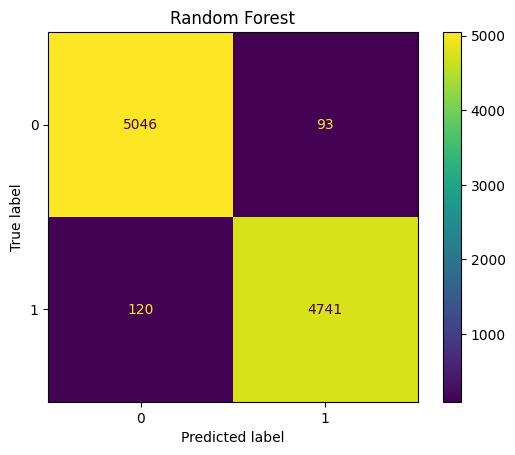

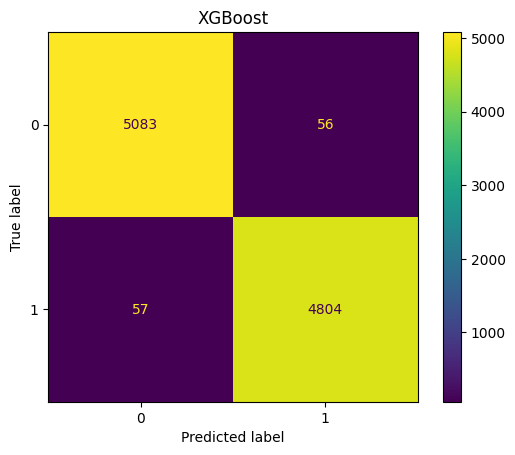

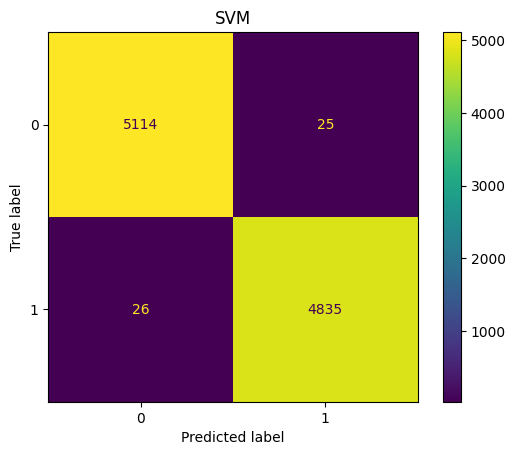

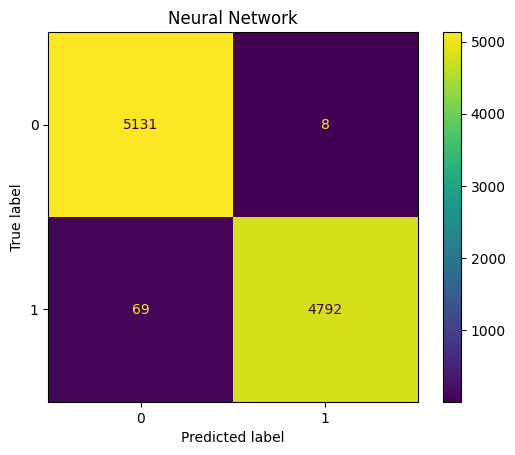

In [ ]:
for name, model in models.items():

    if name in ["SVM", "Neural Network"]:
        pred = model.predict(X_test_scaled)

    else:
        pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot()

    plt.title(name)

    plt.show()

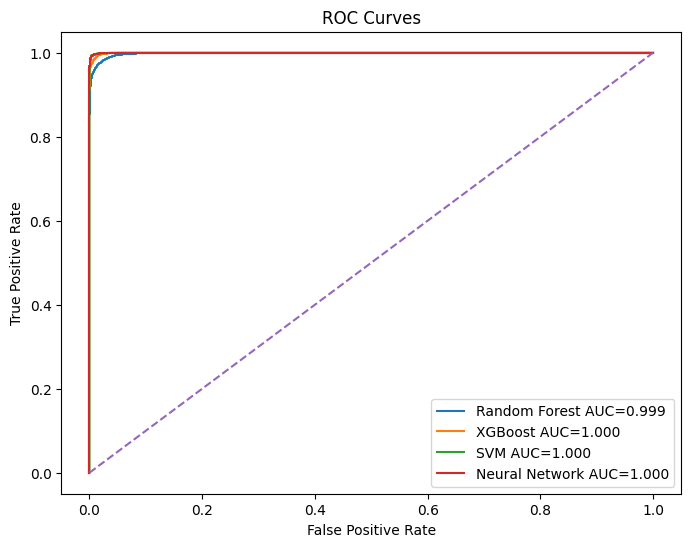

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    if name in ["SVM", "Neural Network"]:

        prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        prob = model.predict_proba(
            X_test
        )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={roc_auc:.3f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()

plt.show()

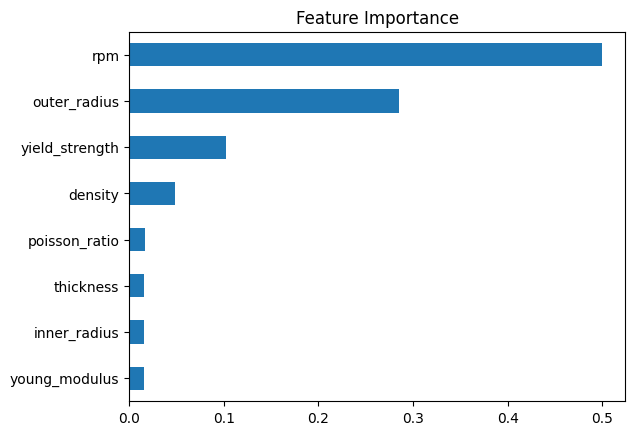

In [ ]:
rf = models["Random Forest"]

importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "Feature Importance"
)

plt.show()